# Requirements

## Logging

In [1]:
import logging
import sys

logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(stream=sys.stdout)],
    force=True,
)

In [2]:
logger = logging.getLogger(__name__)

## Imports

In [3]:
from netbalance.configs import A_DEGREE_RATIO_RESULTS_DIR, OptimizerConfig
from netbalance.data.bipartite_graph_data import BGData, BGTrainTestSpliter
from netbalance.features.hmdad import HMDADDataset
from netbalance.models.degree_ratio import DegreeRatioHandlerFactory
from netbalance.optimization.degree_ratio import DegreeRatioTester, DegreeRatioTrainer
from netbalance.evaluation import repeated_cross_validation
from netbalance.utils.result import save_all_results_for_expr

## Notebook Configs

In [4]:
model_name = "a_degree_ratio"
balance_method = "rho"
dataset = "hmdad"
fontname = "Helvetica"
save_figs = False
num_negative_sampling = 5
num_cross_validation = 2
negative_ratio = 1.0
model_result_dir = A_DEGREE_RATIO_RESULTS_DIR


kwargs = {}
ds = HMDADDataset()

## Matplotlib Configs

In [5]:
import matplotlib as mpl

mpl.rc("font", family=fontname)

# Configs

In [6]:
optimizer_config = OptimizerConfig()

# Cross Validation

In [7]:
def get_data():
    return BGData(
        associations=ds.get_associations(with_negatives=True),
        cluster_a_node_names=ds.get_cluster_a_node_names(),
        cluster_b_node_names=ds.get_cluster_b_node_names(),
    )

In [8]:
associations = ds.get_associations(with_negatives=True)

In [9]:
trainer = DegreeRatioTrainer()
tester = DegreeRatioTester()
factory = DegreeRatioHandlerFactory(
    a_node_ids=list(set(associations[:, 0])),
    b_node_ids=list(set(associations[:, 1])),
    use_a=False,
    use_b=True,
    reduction=None,
)

### 5-Fold CV

In [10]:
analyse_name = "5_fold"

In [11]:
import numpy as np

desired_ent_list = np.arange(0.5, 1.0, 0.05).tolist()

print(desired_ent_list)

[0.5, 0.55, 0.6000000000000001, 0.6500000000000001, 0.7000000000000002, 0.7500000000000002, 0.8000000000000003, 0.8500000000000003, 0.9000000000000004, 0.9500000000000004]


In [12]:
auc_list = []

In [13]:
for desired_ent in desired_ent_list:

    general_cv_result = repeated_cross_validation(
        get_data=get_data,
        SplitterClass=BGTrainTestSpliter,
        handler_factory=factory,
        trainer=trainer,
        tester=tester,
        optimizer_config=optimizer_config,
        num_negative_sampling=num_negative_sampling,
        num_cross_validation=num_cross_validation,
        splitter_kwargs={
            "k": 5,
            "train_balance": False,
            "test_balance": True,
            "balance_kwargs": {
                "balance_method": balance_method,
                "negative_ratio": 1.0,
                "max_iter": 10000,
                "delta": 0.5,
                "cooling_rate": 0.99,
                "initial_temp": 10.0,
                "ent_desired": desired_ent,
            },
        },
    )

    auc_list.append(general_cv_result.result.get_result()["AUC"])

2024-11-26 16:33:24,024 [INFO] Progress: 100%|██████████| 5/5 [01:03<00:00, 12.70s/it]


In [14]:
print(auc_list)

[0.828539625052085, 0.8124489013478411, 0.7993360963060464, 0.7842036125164559, 0.7682784652046567, 0.7532864374383168, 0.7361425980099967, 0.7230570439642402, 0.7058416086437842, 0.6971365755054767]


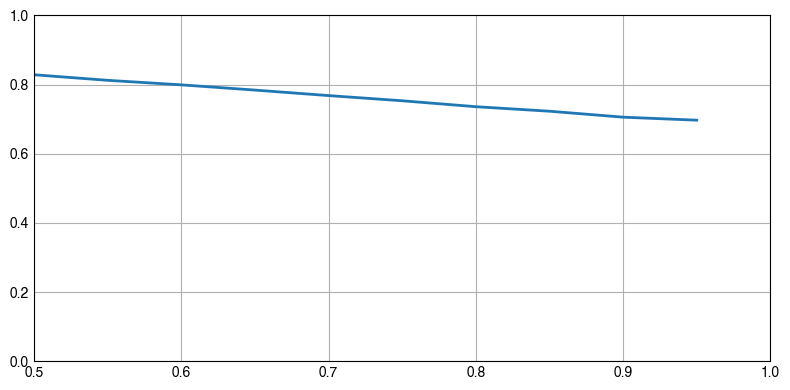

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# make data
x = desired_ent_list
y = auc_list

# plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, linewidth=2.0)

ax.set(ylim=(0, 1), xlim=(0.5, 1.0))

fig.tight_layout()